In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

caps = {}
sohs = {}

## MIT battery dataset

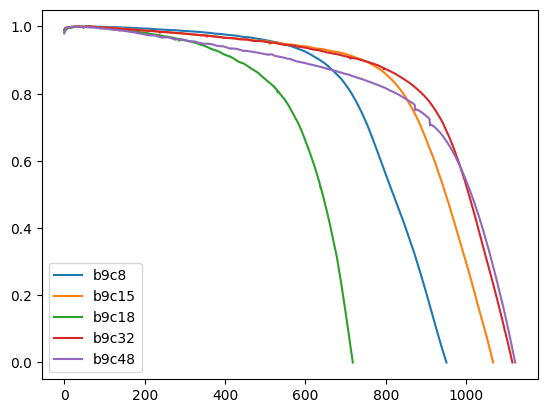

In [2]:
keys = ['b9c8', 'b9c15', 'b9c18', 'b9c32', 'b9c48']
batch = np.load('../../data/raw/batch9.pkl', allow_pickle=True)
for key in keys:
    cap = batch[key]['summary']['QD']
    soh = scaler.fit_transform(cap.reshape(-1, 1))
    caps[f'mit_{key}'] = np.array(cap).flatten()
    sohs[f'mit_{key}'] = np.array(soh).flatten()
    plt.plot(soh, label=f'{key}')
plt.legend()

## TRI battery dataset

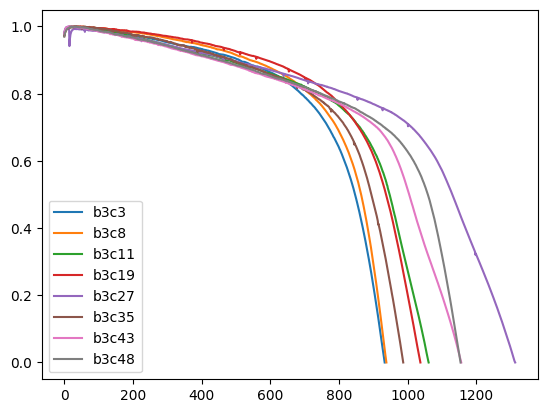

In [3]:
keys = ['b3c3', 'b3c8', 'b3c11', 'b3c19', 'b3c27', 'b3c35', 'b3c43', 'b3c48']
batch = np.load('../../data/raw/batch3.pkl', allow_pickle=True)
for key in keys:
    cap = batch[key]['summary']['QD']
    soh = scaler.fit_transform(cap.reshape(-1, 1))
    caps[f'tri_{key}'] = np.array(cap).flatten()
    sohs[f'tri_{key}'] = np.array(soh).flatten()
    plt.plot(soh, label=f'{key}')
plt.legend()

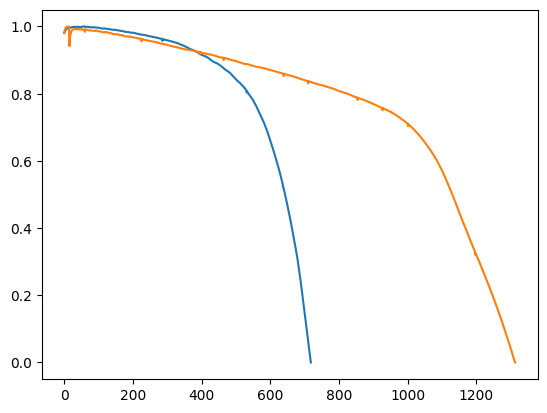

In [4]:
plt.plot(sohs['mit_b9c18'])
plt.plot(sohs['tri_b3c27'])

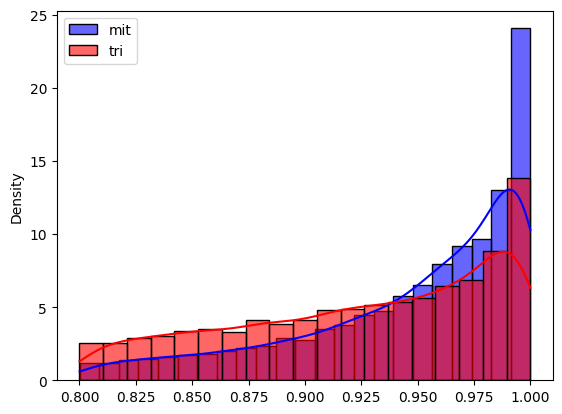

In [5]:
mit, tri = [], []
for key in caps.keys():
    if 'mit' in key:
        mit.append(sohs[key])
    elif 'tri' in key:
        tri.append(sohs[key])

mit = np.concatenate(mit, axis=0)
mit = mit[mit > 0.8]
tri = np.concatenate(tri, axis=0)
tri = tri[tri > 0.8]

sns.histplot(mit, kde=True, color='blue', label='mit', stat="density", alpha=0.6)
sns.histplot(tri, kde=True, color='red', label='tri', stat="density", alpha=0.6)
plt.legend()